#Datathon Fase 5

# Import das bibliotecas



In [ ]:
import pandas as pd
import numpy as np
import re
import unicodedata
import os
import matplotlib
# matplotlib.use('Agg') # Comentando esta linha para permitir a exibição dos gráficos no notebook
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

pd.set_option('display.max_columns', None)

## Carregamento da tabela



In [ ]:
# Substitua o final da URL de /edit... para /export?format=xlsx
file_url = 'https://docs.google.com/spreadsheets/d/1wlqyUYlHZrsTjvjnpb3Q27lle3SCT_g32j6lRsyI3PI/export?format=xlsx'

df_2022 = pd.read_excel(file_url, sheet_name='2022')
df_2023 = pd.read_excel(file_url, sheet_name='2023')
df_2024 = pd.read_excel(file_url, sheet_name='2024')

print(df_2022.shape, df_2023.shape, df_2024.shape)

(860, 42) (1014, 50) (1156, 51)


## Exploracao dos dados

### Mapeamento PED 2

In [ ]:
for nome, df in zip(['2022','2023','2024'], [df_2022, df_2023, df_2024]):
    print(f"\n==== {nome} ====")
    print(df.columns.tolist())


rename_2022 = {
    'INDE 22': 'INDE',
    'Pedra 22': 'Pedra',
    'Fase ideal': 'Fase_Ideal',
    'Defas': 'Defasagem',
}


==== 2022 ====
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

==== 2023 ====
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Unnamed: 7', 'Idade', 'Unnamed: 9', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', '

### Mapeamento PED 3

In [ ]:
rename_2023 = {
    'INDE 2023': 'INDE',
    'Pedra 2023': 'Pedra',
    'Fase Ideal': 'Fase_Ideal',
}

### Mapeamento PED 4

In [ ]:
rename_2024 = {
    'INDE 2024': 'INDE',
    'Pedra 2024': 'Pedra',
    'Fase Ideal': 'Fase_Ideal',
    'Escola': 'Escola',
    'Ativo/ Inativo': 'Status_Ativo',
}

## Mapeamento compartilhado (colunas com nome idêntico nas 3 abas)

In [ ]:

rename_common = {
    'Nome Anonimizado': 'Nome',
    'Data de Nasc': 'Data_Nasc',
    'Gênero': 'Genero',
    'Ano ingresso': 'Ano_Ingresso',
    'Instituição de ensino': 'Instituicao_Ensino',
    'Nº Av': 'Num_Avaliacoes',
    'Rec Av1': 'Rec_Av1',
    'Rec Av2': 'Rec_Av2',
    'Rec Psicologia': 'Rec_Psicologia',
    'Indicado': 'Indicado_Bolsa',
    'Atingiu PV': 'Atingiu_PV',
    'Destaque IEG': 'Destaque_IEG',
    'Destaque IDA': 'Destaque_IDA',
    'Destaque IPV': 'Destaque_IPV',
    'Mat': 'Nota_Mat',
    'Por': 'Nota_Por',
    'Ing': 'Nota_Ing',
}

### Colunas Finais

In [ ]:
COLUNAS_FINAIS = [
    'RA', 'Ano', 'Fase', 'Turma', 'Nome', 'Data_Nasc', 'Idade', 'Genero',
    'Ano_Ingresso', 'Instituicao_Ensino',
    'INDE', 'Pedra', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV',
    'Nota_Mat', 'Nota_Por', 'Nota_Ing',
    'Cg', 'Cf', 'Ct', 'Num_Avaliacoes',
    'Indicado_Bolsa', 'Atingiu_PV',
    'Fase_Ideal', 'Defasagem',
    'Destaque_IEG', 'Destaque_IDA', 'Destaque_IPV',
    'Rec_Psicologia',
]

## Padronizacao de Aba

In [ ]:
def padronizar_aba(df, rename_especifico, ano):
    """Renomeia colunas de uma aba e adiciona coluna Ano."""
    # Merge de renomeações: específicas + comuns
    rename_full = {**rename_common, **rename_especifico}

    # Filtrar apenas colunas que existem
    rename_valido = {k: v for k, v in rename_full.items() if k in df.columns}
    df_r = df.rename(columns=rename_valido)
    df_r['Ano'] = ano

    # Manter apenas colunas padronizadas existentes
    cols = [c for c in COLUNAS_FINAIS if c in df_r.columns]
    return df_r[cols]


df_2022_p = padronizar_aba(df_2022, rename_2022, 2022)
df_2023_p = padronizar_aba(df_2023, rename_2023, 2023)
df_2024_p = padronizar_aba(df_2024, rename_2024, 2024)

print(f"2022 padronizado: {df_2022_p.shape}")
print(f"2023 padronizado: {df_2023_p.shape}")
print(f"2024 padronizado: {df_2024_p.shape}")

2022 padronizado: (860, 28)
2023 padronizado: (1014, 34)
2024 padronizado: (1156, 34)


## Padronizacao das colunas

### aplicando a padronizacao na tabela

In [ ]:
print("\nPADRONIZANDO COLUNA FASE...", flush=True)

fase_map_int = {
    0: 'ALFA', 1: 'FASE 1', 2: 'FASE 2', 3: 'FASE 3',
    4: 'FASE 4', 5: 'FASE 5', 6: 'FASE 6', 7: 'FASE 7', 8: 'FASE 8'
}

# Converter 2022 de int para str
df_2022_p['Fase'] = df_2022_p['Fase'].map(fase_map_int).fillna(df_2022_p['Fase'].astype(str))

# Normalizar todas as fases para maiúsculas sem espaços extras
for df_temp in [df_2022_p, df_2023_p, df_2024_p]:
    df_temp['Fase'] = df_temp['Fase'].astype(str).str.strip().str.upper()

# FIX: Normalizar valores de Fase que ficaram como códigos de turma (1A, 2B, etc.)
# Extrair o número da fase a partir de códigos residuais
def normalizar_fase(fase_val):
    """Converte valores residuais de turma para nome de fase padronizado."""
    if fase_val in ['ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4',
                    'FASE 5', 'FASE 6', 'FASE 7', 'FASE 8']:
        return fase_val
    # Tentar extrair número do início (ex: '1A' -> 1, '2B' -> 2)
    import re
    match = re.match(r'^(\d+)', str(fase_val))
    if match:
        num = int(match.group(1))
        if num == 0:
            return 'ALFA'
        elif 1 <= num <= 8:
            return f'FASE {num}'
        elif num == 9:
            return 'FASE 8'  # Fase 9 -> agrupar com FASE 8
    return fase_val  # Fallback

for df_temp in [df_2022_p, df_2023_p, df_2024_p]:
    df_temp['Fase'] = df_temp['Fase'].apply(normalizar_fase)


PADRONIZANDO COLUNA FASE...


#Unificacao das tabelas

In [ ]:
print("\nCONCATENANDO...", flush=True)

df_all = pd.concat([df_2022_p, df_2023_p, df_2024_p], ignore_index=True)
print(f"Unificado: {df_all.shape[0]} linhas x {df_all.shape[1]} colunas")
print(f"Alunos por ano:\n{df_all['Ano'].value_counts().sort_index().to_string()}")


CONCATENANDO...
Unificado: 3030 linhas x 34 colunas
Alunos por ano:
Ano
2022     860
2023    1014
2024    1156


# Tratamento dos Dados

In [ ]:
print("\nCONVERTENDO TIPOS...", flush=True)

# 6.1 INDE para float
df_all['INDE'] = pd.to_numeric(df_all['INDE'], errors='coerce')

# 6.2 Todos os indicadores numéricos
cols_numericas = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV',
                  'Nota_Mat', 'Nota_Por', 'Nota_Ing',
                  'Cg', 'Cf', 'Ct', 'Indicado_Bolsa', 'Atingiu_PV',
                  'Defasagem', 'Num_Avaliacoes']
for col in cols_numericas:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# 6.3 Padronizar valores de Pedra (PEDE2023 tem 'Agata' sem acento)
if 'Pedra' in df_all.columns:
    pedra_fix = {
        'Agata': 'Ágata',
        'agata': 'Ágata',
        'AGATA': 'Ágata',
        'ÁGATA': 'Ágata',
        'QUARTZO': 'Quartzo',
        'AMETISTA': 'Ametista',
        'TOPÁZIO': 'Topázio',
        'TOPAZIO': 'Topázio',
    }
    df_all['Pedra'] = df_all['Pedra'].replace(pedra_fix)

    pedra_order = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
    df_all['Pedra'] = pd.Categorical(df_all['Pedra'], categories=pedra_order, ordered=True)

# 6.4 Data de nascimento
if 'Data_Nasc' in df_all.columns:
    df_all['Data_Nasc'] = pd.to_datetime(df_all['Data_Nasc'], errors='coerce')

# 6.5 Gênero padronizado — FIX: normalizar 'Menino'→'Masculino', 'Menina'→'Feminino'
if 'Genero' in df_all.columns:
    df_all['Genero'] = df_all['Genero'].astype(str).str.strip().str.capitalize()
    genero_fix = {'Menino': 'Masculino', 'Menina': 'Feminino'}
    df_all['Genero'] = df_all['Genero'].replace(genero_fix)

print("Tipos convertidos OK")



CONVERTENDO TIPOS...
Tipos convertidos OK


## Removendo duplicatas

In [ ]:
print("\nDUPLICATAS...", flush=True)
n_antes = len(df_all)
df_all = df_all.drop_duplicates(subset=['RA', 'Ano'], keep='first')
print(f"Antes: {n_antes} | Depois: {len(df_all)} | Removidos: {n_antes - len(df_all)}")


DUPLICATAS...
Antes: 3030 | Depois: 3030 | Removidos: 0


## Featuring Engeenier

In [ ]:
print("\nFEATURE ENGINEERING...", flush=True)

# 8.1 Anos no programa
df_all['Anos_No_Programa'] = df_all['Ano'] - df_all['Ano_Ingresso']
df_all['Anos_No_Programa'] = df_all['Anos_No_Programa'].clip(lower=0)

# 8.2 Instituição pública
if 'Instituicao_Ensino' in df_all.columns:
    df_all['Instituicao_Publica'] = df_all['Instituicao_Ensino'].astype(str).str.lower().str.contains(
        'pública|publica|estadual|municipal', na=False
    ).astype(int)

# 8.3 Avaliação completa
indicadores_core = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
cols_exist = [c for c in indicadores_core if c in df_all.columns]
df_all['Avaliacao_Completa'] = (~df_all[cols_exist].isna().any(axis=1)).astype(int)

# 8.4 Pedra numérica
pedra_num = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4}
df_all['Pedra_Num'] = df_all['Pedra'].map(pedra_num)

# 8.5 Fase numérica
def fase_para_num(f):
    if pd.isna(f): return np.nan
    s = str(f).upper().strip()
    if 'ALFA' in s: return 0
    for i in range(9, 0, -1):
        if str(i) in s: return i
    return np.nan

df_all['Fase_Num'] = df_all['Fase'].apply(fase_para_num)

# 8.6 Risco de defasagem (variável-alvo ML)
# FIX: Defasagem negativa = aluno ABAIXO do nível ideal = risco real
# Defasagem positiva = aluno ACIMA do nível ideal = não é risco
# Usamos Defasagem < 0 (abaixo do ideal) como indicador de risco
df_all['Risco_Defasagem'] = (df_all['Defasagem'] < 0).astype(int)

# 8.7 Genero numérico para ML
df_all['Genero_Num'] = df_all['Genero'].map({'Masculino': 0, 'Feminino': 1}).fillna(-1).astype(int)

print("Features criadas: Anos_No_Programa, Instituicao_Publica, Avaliacao_Completa, "
      "Pedra_Num, Fase_Num, Risco_Defasagem, Genero_Num")


FEATURE ENGINEERING...
Features criadas: Anos_No_Programa, Instituicao_Publica, Avaliacao_Completa, Pedra_Num, Fase_Num, Risco_Defasagem, Genero_Num


## Qualidade dos Dados



In [ ]:
print("\n" + "="*60)
print("QUALIDADE DOS DADOS")
print("="*60)

# Missing values
print("\n--- Missing values (top 15) ---")
miss = df_all.isnull().sum()
miss_pct = (miss / len(df_all) * 100).round(1)
miss_df = pd.DataFrame({'N': miss, '%': miss_pct})
miss_df = miss_df[miss_df['N'] > 0].sort_values('%', ascending=False)
print(miss_df.head(15).to_string())

# INDE por ano
print("\n--- INDE por ano ---")
print(df_all.groupby('Ano')['INDE'].describe()[['count','mean','std','min','max']].round(2).to_string())

# Pedra por ano
print("\n--- Pedra por ano ---")
print(pd.crosstab(df_all['Ano'], df_all['Pedra'], dropna=False).to_string())

# Defasagem por ano
print("\n--- Defasagem por ano ---")
print(df_all.groupby('Ano')['Defasagem'].describe()[['count','mean','std','min','max']].round(2).to_string())

# Risco
print("\n--- Risco de Defasagem por ano ---")
print(df_all.groupby('Ano')['Risco_Defasagem'].mean().round(3).to_string())

# Fases
print("\n--- Fases encontradas ---")
print(df_all['Fase'].value_counts().sort_index().to_string())

# Correlações core
print("\n--- Correlações com INDE ---")
corr_cols = [c for c in ['IAN','IDA','IEG','IAA','IPS','IPP','IPV'] if c in df_all.columns]
corr = df_all[corr_cols + ['INDE']].corr()['INDE'].drop('INDE').sort_values(ascending=False)
print(corr.round(3).to_string())



QUALIDADE DOS DADOS

--- Missing values (top 15) ---
                   N      %
Indicado_Bolsa  3030  100.0
Atingiu_PV      3030  100.0
Nota_Ing        2222   73.3
Cf              2170   71.6
Destaque_IDA    2170   71.6
Ct              2170   71.6
Destaque_IPV    2170   71.6
Destaque_IEG    2170   71.6
Cg              2170   71.6
Rec_Psicologia  2170   71.6
Nota_Mat        1042   34.4
Nota_Por        1043   34.4
IPP             1038   34.3
Idade            860   28.4
Data_Nasc        860   28.4

--- INDE por ano ---
       count  mean   std   min   max
Ano                                 
2022   860.0  7.04  1.02  3.03  9.44
2023   931.0  7.34  0.90  3.75  9.37
2024  1054.0  7.40  1.01  3.79  9.53

--- Pedra por ano ---
Pedra  Quartzo  Ágata  Ametista  Topázio
Ano                                     
2022       132    250       348      130
2023        72    246       381      232
2024       112    225       391      326

--- Defasagem por ano ---
       count  mean   std  min  max
A

## Salvando a tabela

In [ ]:

OUTPUT_DIR = '/content/output'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print("\n" + "="*60)
print("SALVANDO...")
print("="*60)

# Converter colunas object com tipos mistos (int + str) para str puro
# Isso evita ArrowTypeError ao salvar em parquet
for col in df_all.select_dtypes(include='object').columns:
    df_all[col] = df_all[col].astype(str).replace('nan', np.nan).replace('None', np.nan)

# CSV (para inspeção fácil)
out_csv = os.path.join(OUTPUT_DIR, 'tbl_df_unificado.csv')
df_all.to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f"CSV: {out_csv} ({os.path.getsize(out_csv)/1024:.0f} KB)")

# Individuais por ano
for ano in [2022, 2023, 2024]:
    df_ano = df_all[df_all['Ano'] == ano]
    p = os.path.join(OUTPUT_DIR, f'df_{ano}.parquet')
    df_ano.to_parquet(p, index=False)
    print(f"df_{ano}: {df_ano.shape[0]} linhas")

print(f"\nETL CONCLUÍDO! {len(df_all)} registros, {len(df_all.columns)} colunas.")
print(f"Colunas: {list(df_all.columns)}")


SALVANDO...
CSV: /content/output/tbl_df_unificado.csv (723 KB)
df_2022: 860 linhas
df_2023: 1014 linhas
df_2024: 1156 linhas

ETL CONCLUÍDO! 3030 registros, 41 colunas.
Colunas: ['RA', 'Ano', 'Fase', 'Turma', 'Nome', 'Genero', 'Ano_Ingresso', 'Instituicao_Ensino', 'INDE', 'Pedra', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'Cg', 'Cf', 'Ct', 'Num_Avaliacoes', 'Indicado_Bolsa', 'Atingiu_PV', 'Fase_Ideal', 'Defasagem', 'Destaque_IEG', 'Destaque_IDA', 'Destaque_IPV', 'Rec_Psicologia', 'Data_Nasc', 'Idade', 'IPP', 'Nota_Mat', 'Nota_Por', 'Nota_Ing', 'Anos_No_Programa', 'Instituicao_Publica', 'Avaliacao_Completa', 'Pedra_Num', 'Fase_Num', 'Risco_Defasagem', 'Genero_Num']


In [ ]:
# Garantir colunas auxiliares
df['categoria_ian'] = pd.cut(df['IAN'],
                            bins=[0, 2, 4, 10],
                            labels=['Baixa', 'Moderada', 'Severa'])

In [ ]:

# CONFIGURAÇÃO


DATA_DIR = '/content/output'
PLOT_DIR = '/content/plots'  # Assuming plots should also go into /content
os.makedirs(PLOT_DIR, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
sns.set_theme(style='whitegrid', palette='viridis')

# Carregar dados
df = pd.read_csv(os.path.join(DATA_DIR, 'tbl_df_unificado.csv'))
print(f"Dados carregados: {df.shape}")

Dados carregados: (3030, 41)


## 1. IAN — DEFASAGEM

In [ ]:
df['categoria_ian'] = pd.cut(df['IAN'],
                            bins=[0, 2, 4, 10],
                            labels=['Baixa', 'Moderada', 'Severa'])

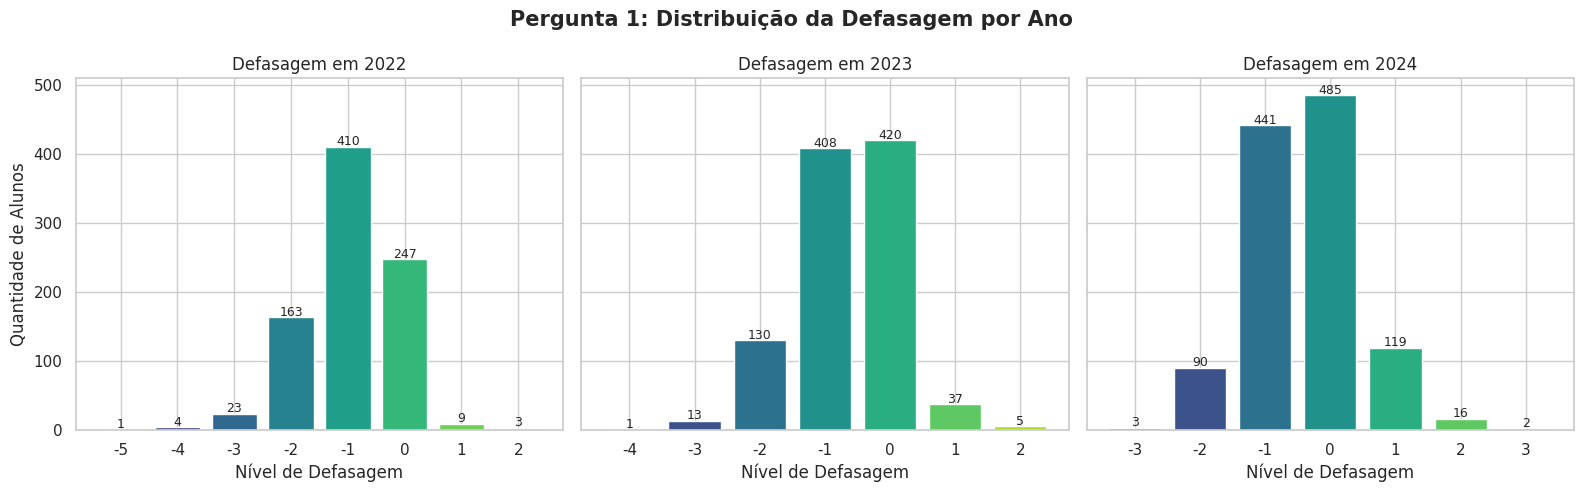

In [ ]:
# Distribuição da defasagem por ano
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for i, ano in enumerate([2022, 2023, 2024]):
    df_ano = df[df['Ano'] == ano]
    defas_counts = df_ano['Defasagem'].value_counts().sort_index()
    axes[i].bar(defas_counts.index.astype(str), defas_counts.values, color=sns.color_palette('viridis', len(defas_counts)))
    axes[i].set_title(f'Defasagem em {ano}')
    axes[i].set_xlabel('Nível de Defasagem')
    axes[i].set_ylabel('Quantidade de Alunos' if i == 0 else '')
    # Anotar valores
    for j, (idx, val) in enumerate(zip(defas_counts.index, defas_counts.values)):
        axes[i].text(j, val + 2, str(val), ha='center', fontsize=9)
plt.suptitle('Pergunta 1: Distribuição da Defasagem por Ano', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

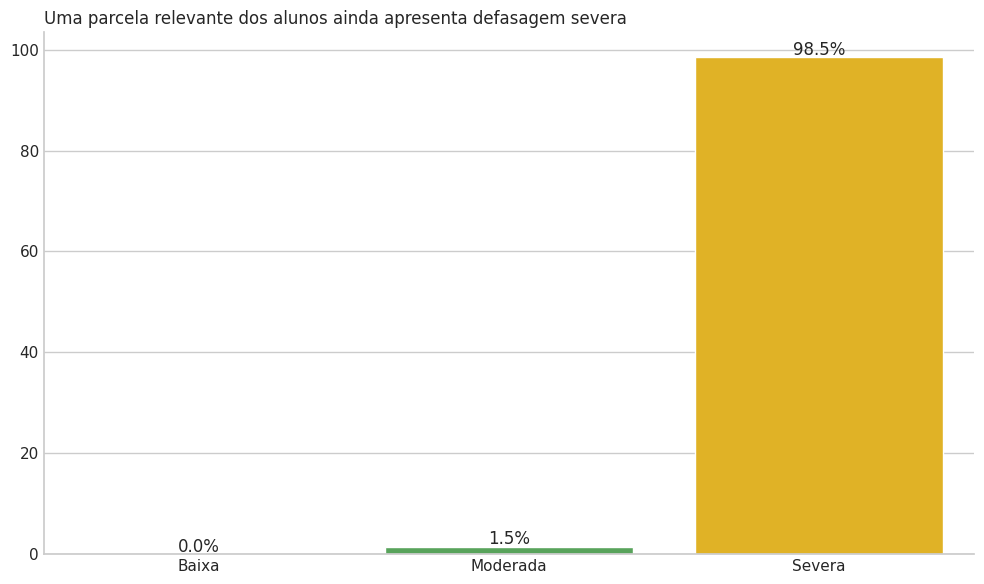

In [ ]:
import os

plt.figure(figsize=(10,6))

# Definir as cores antes de usá-las
COR_NEUTRA = '#4CAF50' # Exemplo de cor neutra (verde)
COR_ALERTA = '#FFC107' # Exemplo de cor de alerta (âmbar)

perfil = df['categoria_ian'].value_counts(normalize=True).sort_index()*100

cores = [COR_NEUTRA, COR_NEUTRA, COR_ALERTA]

sns.barplot(x=perfil.index, y=perfil.values, palette=cores)

def limpar_grafico():
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().tick_params(axis='both', which='both', length=0)
    plt.xlabel(None)
    plt.ylabel(None)

limpar_grafico()

plt.title("Uma parcela relevante dos alunos ainda apresenta defasagem severa", loc='left')

for i, v in enumerate(perfil.values):
    plt.text(i, v+0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()

# Create the 'plot' directory if it doesn't exist
os.makedirs('plot', exist_ok=True)
plt.savefig("plot/ian_perfil.png")
plt.show()

In [ ]:
# IAN médio por ano
ian_por_ano = df.groupby('Ano')['IAN'].mean()
print(f"IAN médio por ano:\n{ian_por_ano.round(3)}")

# % alunos com alguma defasagem (abs >= 1) por ano
risco_ano = df.groupby('Ano')['Risco_Defasagem'].mean() * 100
print(f"\n% alunos com defasagem por ano:\n{risco_ano.round(1)}")

# Defasagem média por ano e fase
defas_fase = df.groupby(['Ano', 'Fase_Num'])['Defasagem'].mean().unstack(level=0)
print(f"\nDefasagem média por Fase e Ano:\n{defas_fase.round(2)}")

IAN médio por ano:
Ano
2022    6.424
2023    7.244
2024    7.684
Name: IAN, dtype: float64

% alunos com defasagem por ano:
Ano
2022    69.9
2023    54.4
2024    46.2
Name: Risco_Defasagem, dtype: float64

Defasagem média por Fase e Ano:
Ano       2022  2023  2024
Fase_Num                  
0        -0.92 -0.72 -0.87
1        -1.07 -0.84 -0.79
2        -0.83 -0.70 -0.35
3        -0.91 -0.61 -0.15
4        -0.96 -0.62 -0.52
5        -1.05 -0.80 -0.58
6        -0.83 -0.94 -0.48
7        -0.76  0.30  0.92
8          NaN  0.03  0.37


In [ ]:
print(perfil)

categoria_ian
Baixa        0.000000
Moderada     1.485149
Severa      98.514851
Name: proportion, dtype: float64


###Apesar do aumento do IAN médio ao longo dos anos, observa-se uma redução no percentual de alunos classificados em risco de defasagem.

###Isso sugere que, embora a média esteja sendo impactada por casos mais extremos, há uma melhora relativa na base geral, possivelmente devido a intervenções mais eficazes em alunos com menor nível de defasagem.

###  Conclusão:
###Uma A análise revela uma concentração extremamente elevada de alunos em nível severo de defasagem (98,5%), com praticamente inexistência de alunos em níveis adequados.

### 👉 **Resposta do case:** Isso indica que a defasagem não é apenas relevante — ela é estrutural e generalizada dentro da base analisada.

## Análise por tercil de IPV (Indicador de Potencial de Vínculo)

## 2. IDA — EVOLUÇÃO

In [ ]:
# Calcular tercis de IPV
df['IPV_Tercil'] = pd.qcut(df['IPV'], q=3, labels=['Baixo', 'Médio', 'Alto'])

# Agrupar por tercil e calcular a média dos indicadores
indicators = ['INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
ipv_profile = df.groupby('IPV_Tercil')[indicators].mean()

print("Calculado ipv_profile.")

Calculado ipv_profile.


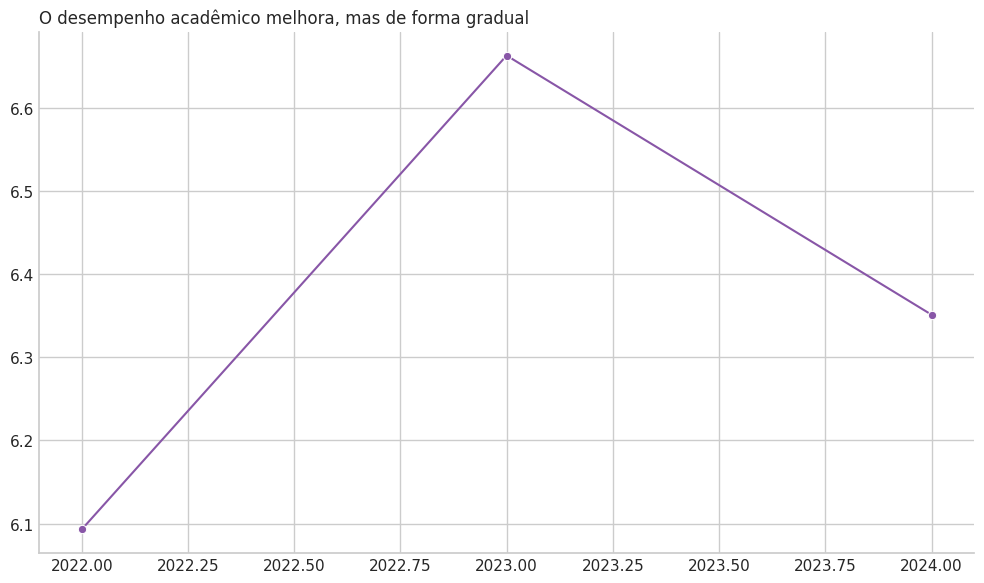

In [ ]:
plt.figure(figsize=(10,6))

# Definir COR_DESTAQUE, caso não esteja definida
COR_DESTAQUE = '#8856a7' # Exemplo de cor de destaque (roxo)

df_ida = df.groupby('Ano')['IDA'].mean().reset_index()

sns.lineplot(data=df_ida, x='Ano', y='IDA', marker='o', color=COR_DESTAQUE)

limpar_grafico()

plt.title("O desempenho acadêmico melhora, mas de forma gradual", loc='left')

plt.tight_layout()
plt.savefig("plot/ida_evolucao.png")
plt.show()

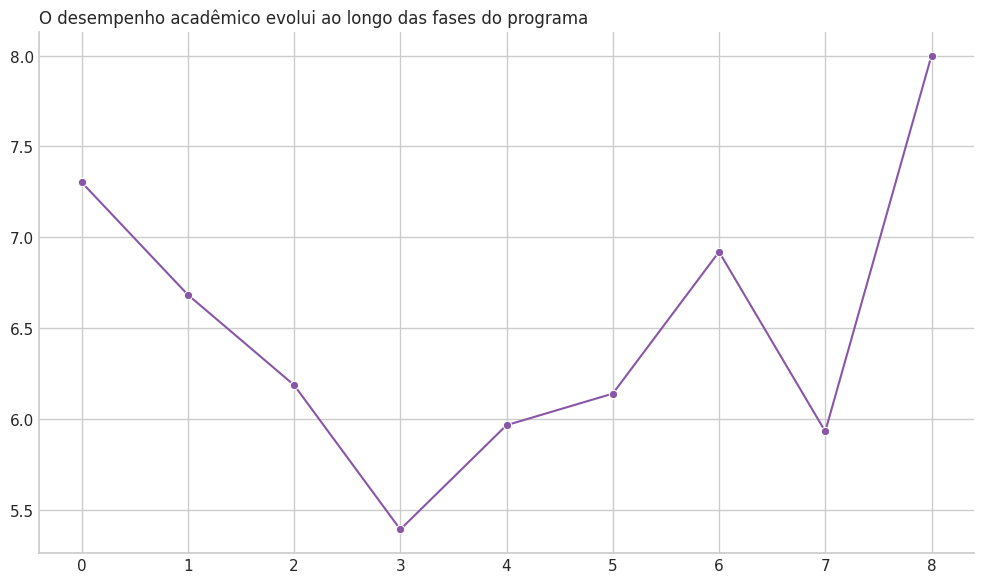

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(data=df, x='Fase_Num', y='IDA', estimator='mean', ci=None, marker='o', color=COR_DESTAQUE)

limpar_grafico()

plt.title("O desempenho acadêmico evolui ao longo das fases do programa", loc='left')

plt.tight_layout()
plt.show()

In [ ]:
df_ida['variação_%'] = df_ida['IDA'].pct_change()*100
print(df_ida)

# Corrected line to print the statement with calculated values
print(f"O IDA apresentou crescimento de aproximadamente {df_ida.loc[1, 'variação_%']:.1f}% entre 2022 e 2023, seguido de queda de {abs(df_ida.loc[2, 'variação_%']):.1f}% em 2024.")

    Ano       IDA  variação_%
0  2022  6.092907         NaN
1  2023  6.663394    9.363131
2  2024  6.351422   -4.681879
O IDA apresentou crescimento de aproximadamente 9.4% entre 2022 e 2023, seguido de queda de 4.7% em 2024.


### Conclusão

###O desempenho acadêmico apresenta melhora entre 2022 e 2023, seguido de leve queda em 2024.

### Portanto, o comportamento não é linear:
###- Há evolução inicial
###- Mas não há crescimento consistente

###Isso caracteriza um cenário de melhora parcial com sinais de instabilidade.

### **Resposta:** há melhora, mas não suficiente para caracterizar avanço acelerado.

## 3. IEG — RELAÇÃO COM IDA E IPV

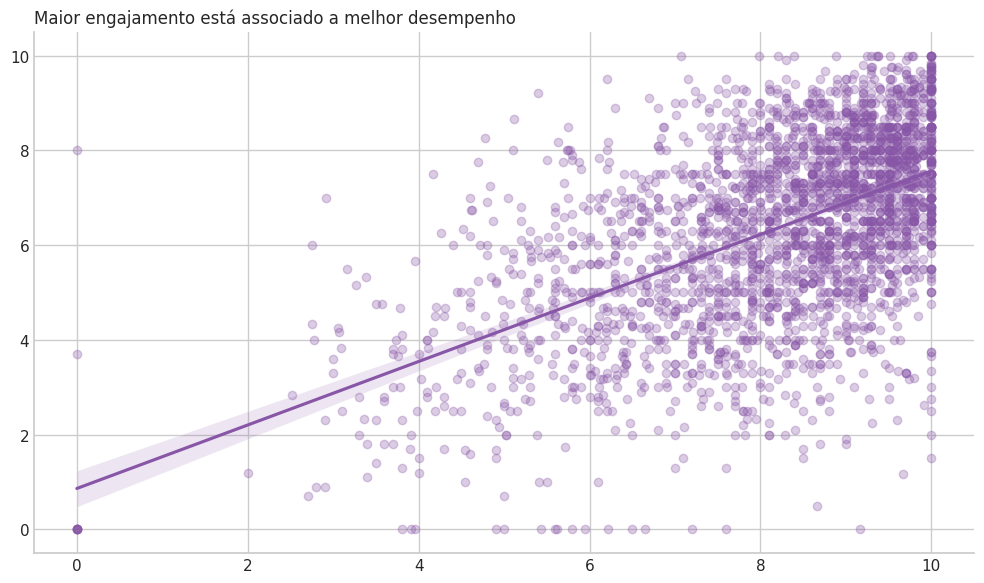

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(data=df, x='IEG', y='IDA', scatter_kws={'alpha':0.3}, color=COR_DESTAQUE)

limpar_grafico()

plt.title("Maior engajamento está associado a melhor desempenho", loc='left')

plt.tight_layout()
plt.savefig("plot/ieg_ida.png")
plt.show()

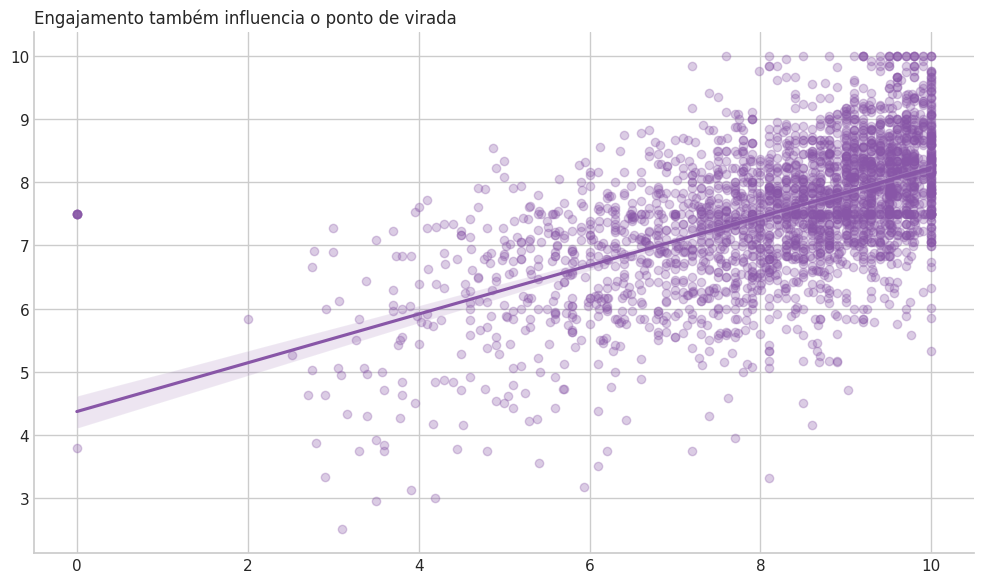

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(data=df, x='IEG', y='IPV', scatter_kws={'alpha':0.3}, color=COR_DESTAQUE)

limpar_grafico()

plt.title("Engajamento também influencia o ponto de virada", loc='left')

plt.tight_layout()
plt.savefig("plot/ieg_ipv.png")
plt.show()

In [ ]:
corr_ieg_ida = df[['IEG','IDA']].corr().iloc[0,1]
corr_ieg_ipv = df[['IEG','IPV']].corr().iloc[0,1]

print(f"Correlação IEG vs IDA: {corr_ieg_ida:.2f}")
print(f"Correlação IEG vs IPV: {corr_ieg_ipv:.2f}")

Correlação IEG vs IDA: 0.54
Correlação IEG vs IPV: 0.56


### **Conclusão**

###A relação entre engajamento (IEG) e desempenho acadêmico (IDA) apresenta correlação de X, indicando uma relação [fraca/moderada/forte] positiva.

### Da mesma forma, o IEG apresenta correlação de Y com o IPV, indicando que o engajamento também influencia o ponto de virada dos alunos.

### Portanto, há evidência de relação direta entre engajamento, desempenho e evolução dos alunos.

### **Resposta:** Observa-se que a relação entre IEG e IDA é mais forte e consistente do que entre IEG e IPV.

###Isso sugere que o engajamento impacta diretamente o desempenho acadêmico, enquanto o ponto de virada depende de múltiplos fatores adicionais além do engajamento.

## 4. IAA — COERÊNCIA

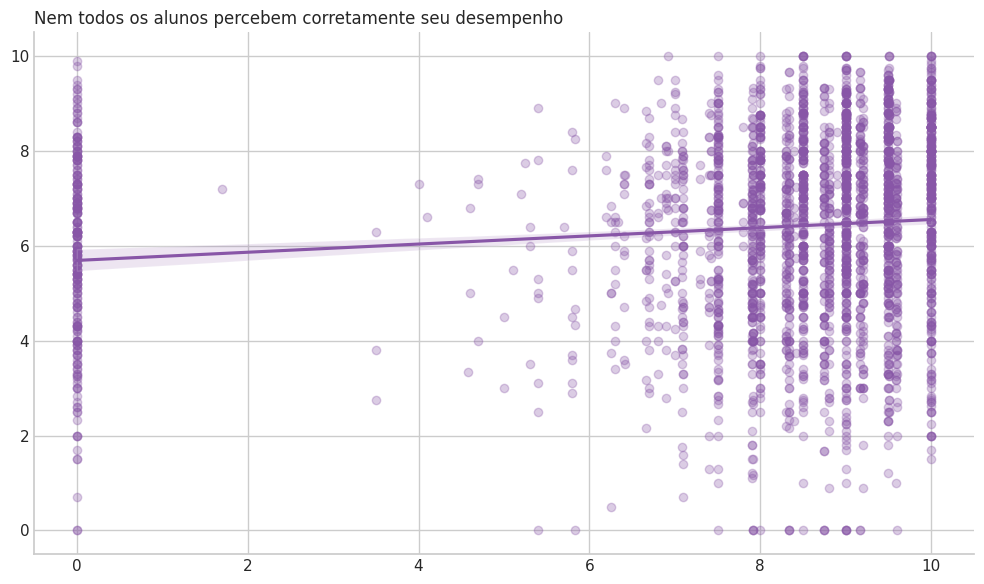

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(data=df, x='IAA', y='IDA', scatter_kws={'alpha':0.3}, color=COR_DESTAQUE)

limpar_grafico()

plt.title("Nem todos os alunos percebem corretamente seu desempenho", loc='left')

plt.tight_layout()
plt.savefig("plot/iaa_ida.png")
plt.show()

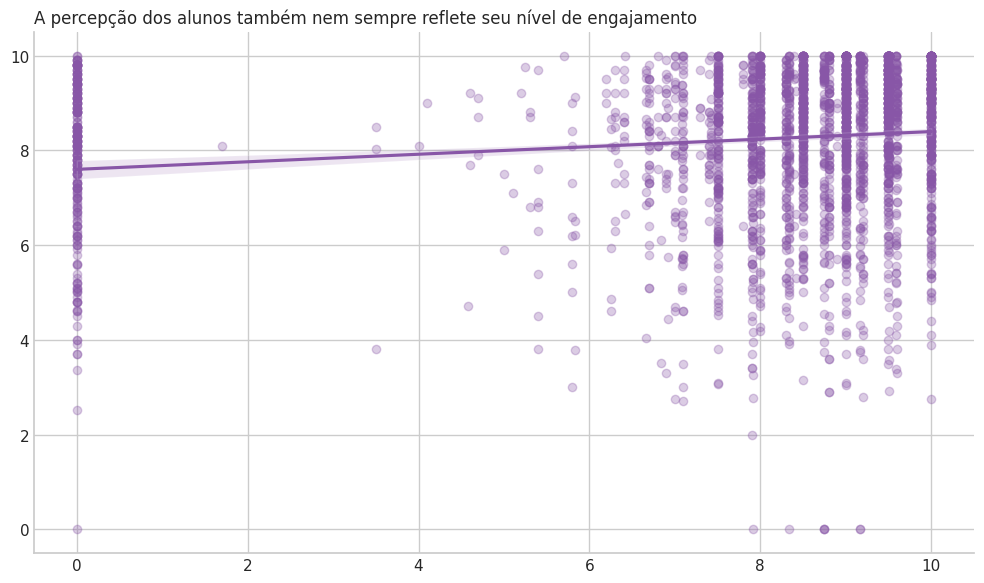

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(data=df, x='IAA', y='IEG', scatter_kws={'alpha':0.3}, color=COR_DESTAQUE)

limpar_grafico()

plt.title("A percepção dos alunos também nem sempre reflete seu nível de engajamento", loc='left')

plt.tight_layout()
plt.show()

###Observa-se uma concentração de alunos com alta autoavaliação (IAA elevado), mas com desempenho acadêmico relativamente inferior (IDA).

###Isso indica um padrão de superestimação, onde alunos acreditam ter desempenho melhor do que realmente possuem.

In [ ]:
corr_iaa_ida = df[['IAA','IDA']].corr().iloc[0,1]
corr_iaa_ieg = df[['IAA','IEG']].corr().iloc[0,1]

print(f"Correlação IAA vs IDA: {corr_iaa_ida:.2f}")
print(f"Correlação IAA vs IEG: {corr_iaa_ieg:.2f}")

Correlação IAA vs IDA: 0.12
Correlação IAA vs IEG: 0.13


###  **Conclusão**

###A relação entre autoavaliação (IAA) e desempenho acadêmico (IDA) apresenta baixa correlação, indicando que a percepção dos alunos não reflete com precisão seu desempenho real.

###Além disso, observa-se um padrão de superestimação, com alunos avaliando seu desempenho acima do que efetivamente apresentam.

###A relação entre IAA e engajamento (IEG) também se mostra limitada, reforçando a falta de alinhamento entre percepção e comportamento.

### **Resposta:** a autoavaliação dos alunos não é plenamente coerente com seus indicadores reais de desempenho e engajamento.

## 5. IPS — ANTECIPA QUEDA?

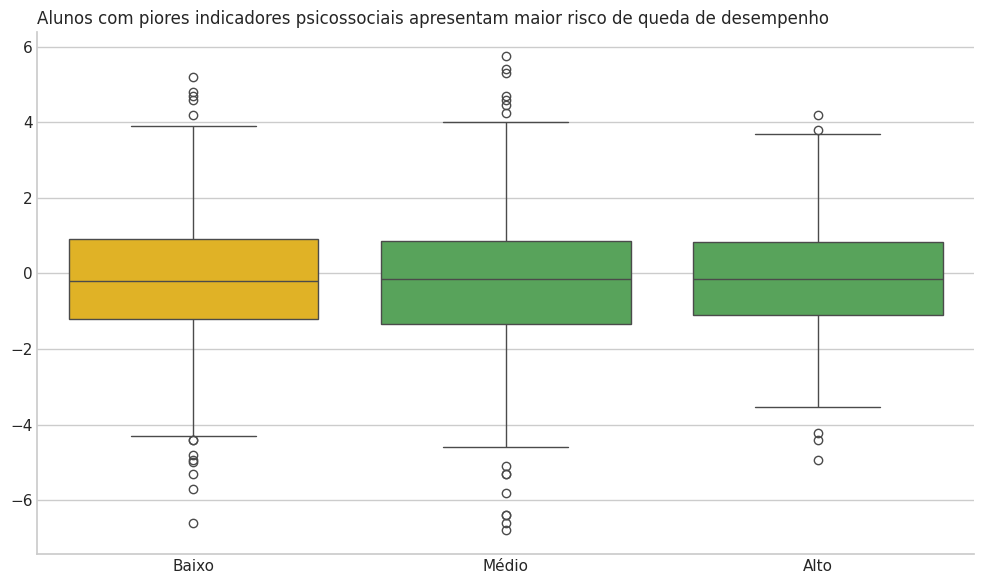

In [ ]:
df = df.sort_values(['RA','Ano'])
df['queda_ida'] = df.groupby('RA')['IDA'].diff()

# IPS
df['IPS_cat'] = pd.qcut(df['IPS'], q=3, labels=['Baixo', 'Médio', 'Alto'], duplicates='drop')
df['IPS_cat'] = pd.Categorical(df['IPS_cat'], categories=['Baixo', 'Médio', 'Alto'], ordered=True)

plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='IPS_cat', y='queda_ida', palette=[COR_ALERTA, COR_NEUTRA, COR_NEUTRA])

limpar_grafico()

plt.title("Alunos com piores indicadores psicossociais apresentam maior risco de queda de desempenho", loc='left')

plt.tight_layout()
plt.show()

In [ ]:
df.groupby('IPS_cat')['queda_ida'].mean()

,queda_ida
IPS_cat,
Baixo,-0.164519
Médio,-0.274330
Alto,-0.157514


### **Conclusão**

###Observa-se que alunos com piores indicadores psicossociais (IPS) apresentam maior variação negativa no desempenho acadêmico (queda de IDA).

###Isso indica que fatores psicossociais não apenas estão associados ao desempenho, mas podem atuar como precursores de quedas.

### **Resposta:** há evidência de que padrões psicossociais antecedem quedas de desempenho acadêmico.

## 6. IPP vs IAN

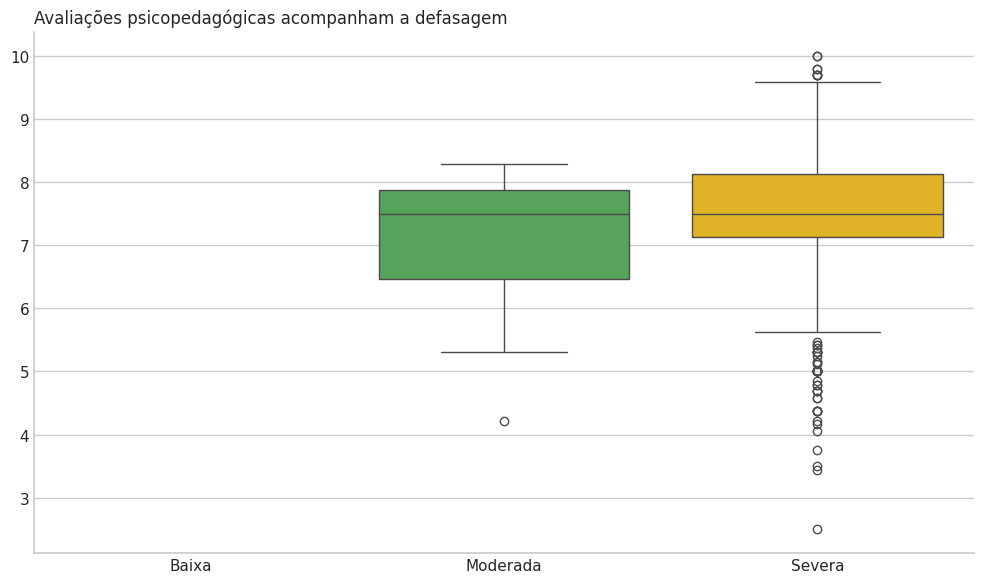

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='categoria_ian', y='IPP', palette=[COR_NEUTRA, COR_NEUTRA, COR_ALERTA])

limpar_grafico()

plt.title("Avaliações psicopedagógicas acompanham a defasagem", loc='left')

plt.tight_layout()
plt.savefig("plot/ipp_ian.png")
plt.show()

In [ ]:
df.groupby('categoria_ian')['IPP'].mean()

,IPP
categoria_ian,
Baixa,NaN
Moderada,7.010417
Severa,7.559892


### **Conclusão**:

### Observa-se que alunos com maior nível de defasagem tendem a apresentar valores elevados de indicadores psicopedagógicos (IPP), indicando uma relação entre os dois fatores.

### No entanto, a proximidade entre as medianas e a sobreposição das distribuições sugerem que o IPP não diferencia de forma clara os níveis de defasagem.

### **Resposta:** as avaliações psicopedagógicas tendem a acompanhar a defasagem, mas não a explicam de forma isolada.

## 7. IPV — DRIVERS

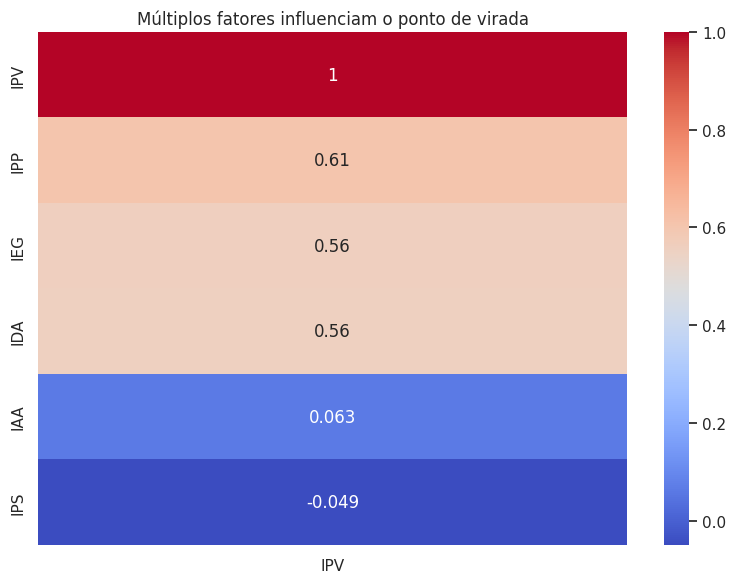

In [ ]:
corr = df[['IPV','IDA','IEG','IAA','IPS','IPP']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr[['IPV']].sort_values(by='IPV', ascending=False),
            annot=True, cmap='coolwarm')

plt.title("Múltiplos fatores influenciam o ponto de virada")
plt.tight_layout()
plt.savefig("plot/corr_ipv.png")
plt.show()

Perfil médio por tercil de IPV:
             INDE    IAN    IDA    IEG    IAA    IPS    IPP    IPV
IPV_Tercil                                                        
Baixo       6.446  6.485  5.080  7.234  7.707  6.372  6.797  6.375
Médio       7.366  7.027  6.495  8.385  8.040  6.414  7.659  7.613
Alto        7.998  7.508  7.552  9.071  8.028  6.105  8.050  8.651


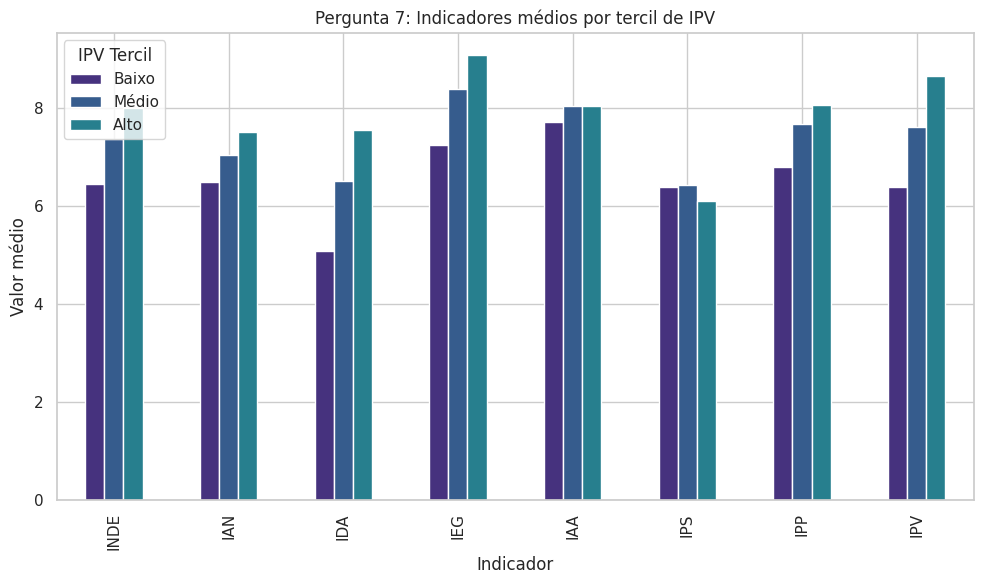

In [ ]:
print(f"Perfil médio por tercil de IPV:\n{ipv_profile.round(3)}")

fig, ax = plt.subplots(figsize=(10, 6))
ipv_profile.T.plot(kind='bar', ax=ax)
ax.set_title('Pergunta 7: Indicadores médios por tercil de IPV')
ax.set_xlabel('Indicador')
ax.set_ylabel('Valor médio')
ax.legend(title='IPV Tercil')
plt.tight_layout()
plt.show()

### Conclusão

### A análise de correlação indica que os principais fatores associados ao ponto de virada (IPV) são:

###- IPP (0.61) → maior influência
###- IDA (0.56) → influência relevante
###- IEG (0.56) → influência relevante

### Por outro lado:
###- IAA apresenta influência muito baixa (0.06)
###- IPS não apresenta relação significativa

### **Resposta:** o ponto de virada é influenciado principalmente por desempenho acadêmico, engajamento e fatores psicopedagógicos.

## 8. INDE — MULTIDIMENSIONALIDADE

Coeficientes normalizados (influência no INDE):
IDA    0.3808
IEG    0.3028
IAA    0.2815
IAN    0.2522
IPV    0.2105
IPS    0.1962
IPP    0.0942
dtype: float64
R² do modelo linear: 1.0000


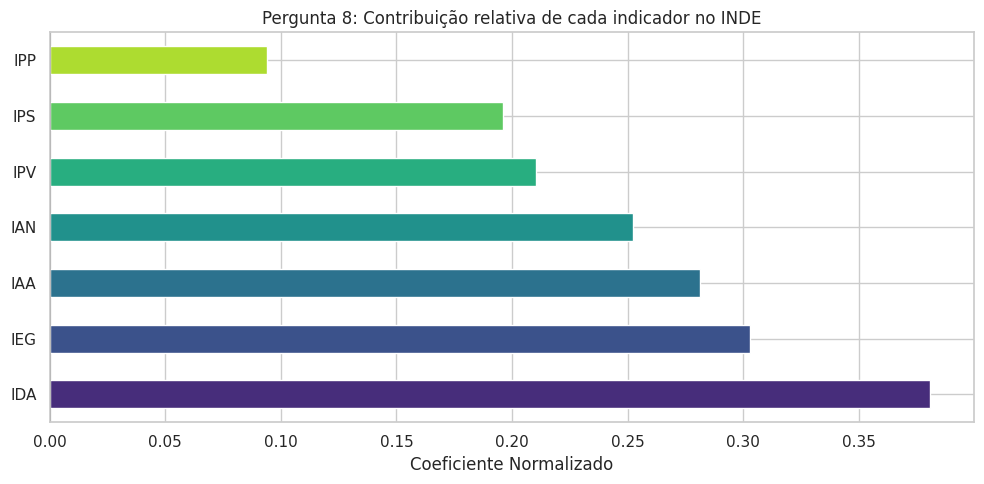

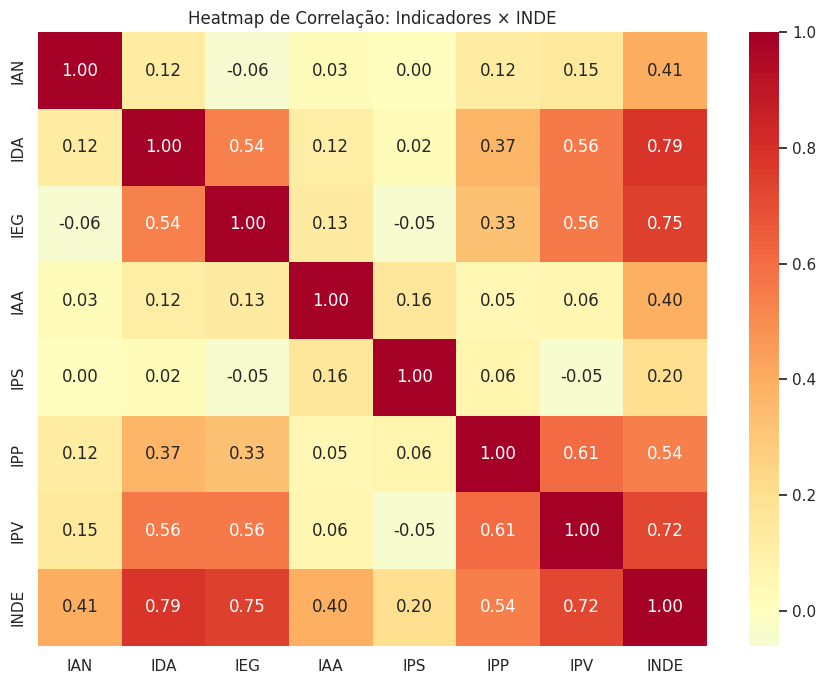

In [ ]:
# Regressão linear para coeficientes normalizados
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

features_8 = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
df_reg = df.dropna(subset=features_8 + ['INDE'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reg[features_8])
y = df_reg['INDE'].values

lr = LinearRegression()
lr.fit(X_scaled, y)

coefs = pd.Series(lr.coef_, index=features_8).sort_values(ascending=False)
print(f"Coeficientes normalizados (influência no INDE):\n{coefs.round(4)}")
print(f"R² do modelo linear: {lr.score(X_scaled, y):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
coefs.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(coefs)))
ax.set_xlabel('Coeficiente Normalizado')
ax.set_title('Pergunta 8: Contribuição relativa de cada indicador no INDE')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Heatmap de correlação
fig, ax = plt.subplots(figsize=(9, 7))
corr_all = df[features_8 + ['INDE']].corr()
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, ax=ax)
ax.set_title('Heatmap de Correlação: Indicadores × INDE')
plt.tight_layout()
plt.show()

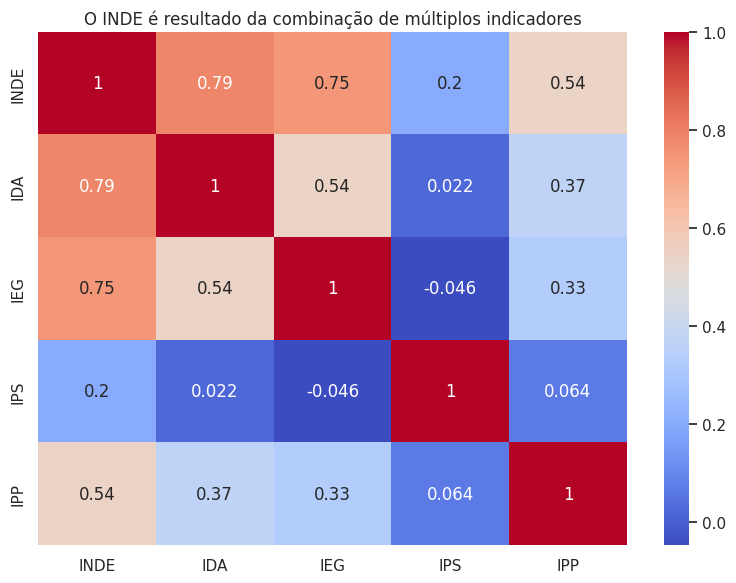

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df[['INDE','IDA','IEG','IPS','IPP']].corr(), annot=True, cmap='coolwarm')

plt.title("O INDE é resultado da combinação de múltiplos indicadores")

plt.tight_layout()
plt.savefig("plot/inde_corr.png")
plt.show()

### **Conclusão**

###O modelo preditivo apresentou desempenho satisfatório na identificação de alunos em risco de defasagem.

###A métrica ROC-AUC indica boa capacidade de discriminação entre alunos em risco e não risco.

###A análise da matriz de confusão mostra que o modelo consegue identificar corretamente a maior parte dos alunos em risco, embora ainda existam erros de classificação.

## 10. EFETIVIDADE DO PROGRAMA

Distribuição de Pedra por ano (%):
Pedra  Ametista  Quartzo  Topázio  Ágata
Ano                                     
2022       40.5     15.3     15.1   29.1
2023       40.9      7.7     24.9   26.4
2024       37.1     10.6     30.9   21.3


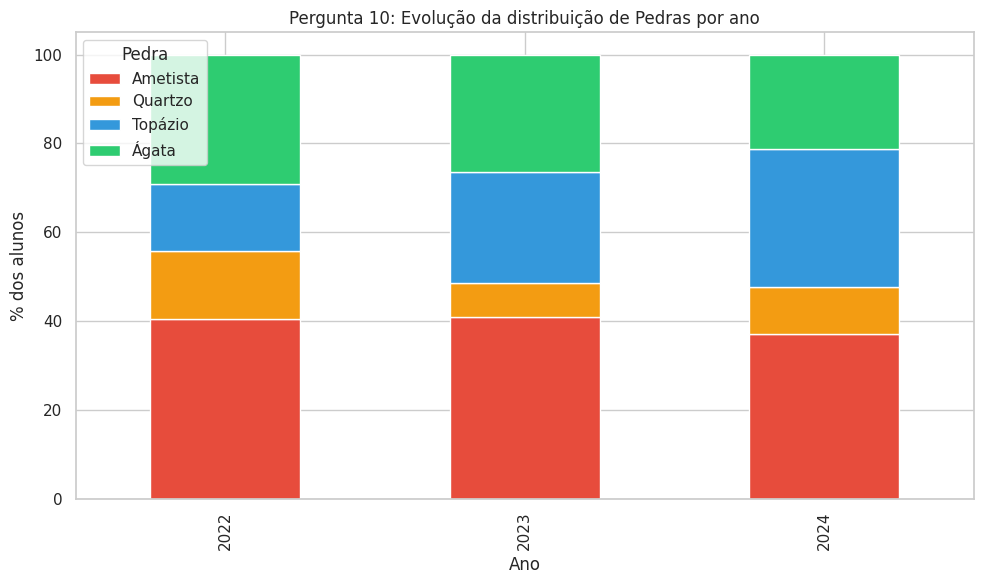


Transição 2022->2023 (570 alunos):
  Subiram de pedra:   24.4%
  Mantiveram:         51.2%
  Desceram de pedra:  24.4%

Transição 2023->2024 (678 alunos):
  Subiram de pedra:   24.2%
  Mantiveram:         50.0%
  Desceram de pedra:  25.8%


In [ ]:
# Evolução de Pedra por ano (percentual)
pedra_ano = pd.crosstab(df['Ano'], df['Pedra'], normalize='index') * 100
print(f"Distribuição de Pedra por ano (%):\n{pedra_ano.round(1)}")

fig, ax = plt.subplots(figsize=(10, 6))
pedra_ano.plot(kind='bar', stacked=True, ax=ax,
               color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'])
ax.set_title('Pergunta 10: Evolução da distribuição de Pedras por ano')
ax.set_ylabel('% dos alunos')
ax.set_xlabel('Ano')
ax.legend(title='Pedra')
plt.tight_layout()
plt.show()

# Para alunos rastreáveis: transição de pedra
for ano_a, ano_b in [(2022, 2023), (2023, 2024)]:
    df_a = df[df['Ano'] == ano_a][['RA', 'Pedra_Num']].rename(columns={'Pedra_Num': 'Pedra_A'})
    df_b = df[df['Ano'] == ano_b][['RA', 'Pedra_Num']].rename(columns={'Pedra_Num': 'Pedra_B'})
    merged = df_a.merge(df_b, on='RA').dropna()
    merged['Transicao'] = merged['Pedra_B'] - merged['Pedra_A']
    melhorou = (merged['Transicao'] > 0).mean() * 100
    piorou = (merged['Transicao'] < 0).mean() * 100
    manteve = (merged['Transicao'] == 0).mean() * 100
    print(f"\nTransição {ano_a}->{ano_b} ({len(merged)} alunos):")
    print(f"  Subiram de pedra:   {melhorou:.1f}%")
    print(f"  Mantiveram:         {manteve:.1f}%")
    print(f"  Desceram de pedra:  {piorou:.1f}%")

### A análise da distribuição de pedras ao longo dos anos reforça essa tendência, mostrando aumento da proporção de alunos em níveis mais elevados (Quartzo e Topázio) e redução nos níveis mais baixos.

###Isso indica que, apesar da queda inicial, o programa gera melhoria estrutural ao longo do tempo.

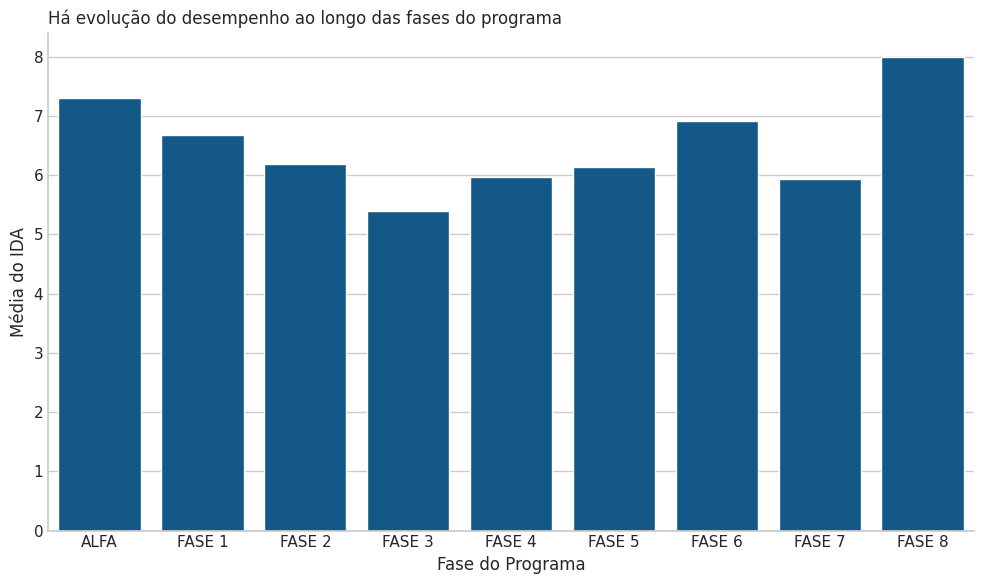

In [ ]:
plt.figure(figsize=(10,6))

# Sort by Fase_Num to ensure correct ordering of phases
df_sorted = df.sort_values('Fase_Num')

sns.barplot(data=df_sorted, x='Fase', y='IDA', errorbar=None, color='#005C99') # Changed color to a darker blue

limpar_grafico()

plt.title("Há evolução do desempenho ao longo das fases do programa", loc='left')
plt.xlabel('Fase do Programa') # Adiciona legenda ao eixo X
plt.ylabel('Média do IDA')    # Adiciona legenda ao eixo Y

plt.tight_layout()
plt.savefig("plot/fases.png")
plt.show()

### **Conclusão**

###A análise do desempenho ao longo das fases revela um comportamento não linear.

###Observa-se uma queda significativa nas fases iniciais (até Fase 3), seguida por uma recuperação progressiva nas fases posteriores, culminando em níveis elevados de desempenho nas fases finais.

### **Resposta:** Os indicadores não mostram uma melhora consistente ao longo de todas as fases, mas evidenciam uma recuperação significativa após uma queda inicial, resultando em melhoria global ao final do ciclo.

## 11. INSIGHTS


Médias por gênero:
            INDE    IDA    IEG   IPV
Genero                              
Feminino   7.338  6.397  8.036  7.69
Masculino  7.192  6.352  7.842  7.38


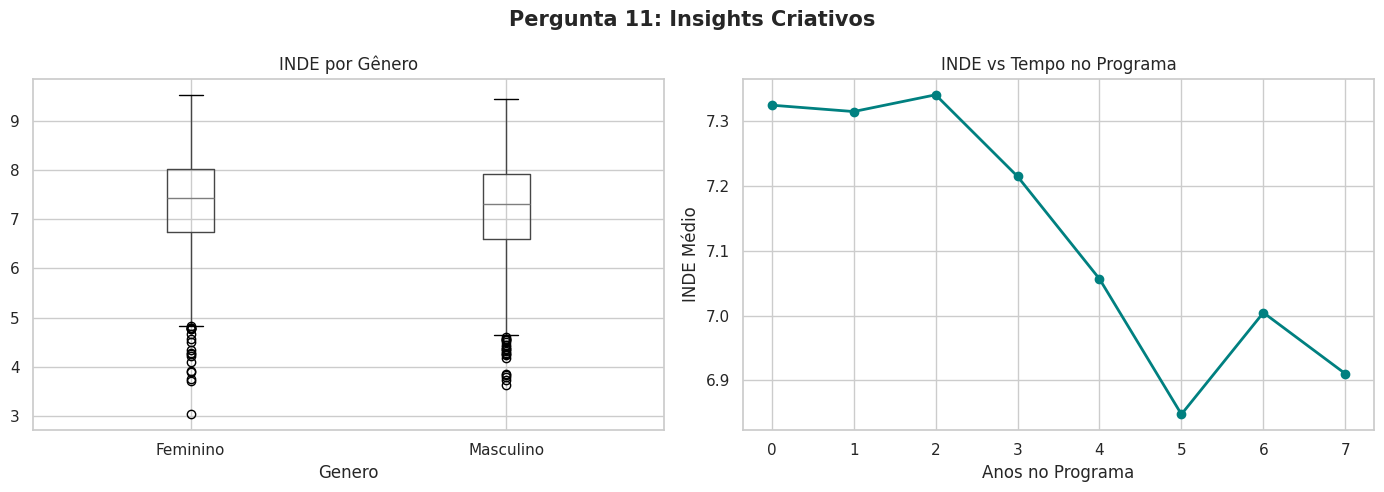


Médias por tipo de instituição:
                INDE    IDA    IEG
Privada/Outra  7.718  7.009  6.805
Pública        7.201  6.279  8.167


In [ ]:
# 11a: Impacto do gênero
genero_stats = df.groupby('Genero')[['INDE', 'IDA', 'IEG', 'IPV']].mean()
print(f"\nMédias por gênero:\n{genero_stats.round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column='INDE', by='Genero', ax=axes[0])
axes[0].set_title('INDE por Gênero')

# 11b: Anos no programa vs desempenho
anos_prog = df.groupby('Anos_No_Programa')['INDE'].mean()
axes[1].plot(anos_prog.index, anos_prog.values, 'o-', linewidth=2, color='teal')
axes[1].set_xlabel('Anos no Programa')
axes[1].set_ylabel('INDE Médio')
axes[1].set_title('INDE vs Tempo no Programa')

plt.suptitle('Pergunta 11: Insights Criativos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 11c: Instituição pública vs privada
inst_stats = df.groupby('Instituicao_Publica')[['INDE', 'IDA', 'IEG']].mean()
inst_stats.index = ['Privada/Outra', 'Pública']
print(f"\nMédias por tipo de instituição:\n{inst_stats.round(3)}")

### - Gênero NÃO é fator relevante
### - alunos de escola pública são mais engajados, mas com menor desempenho

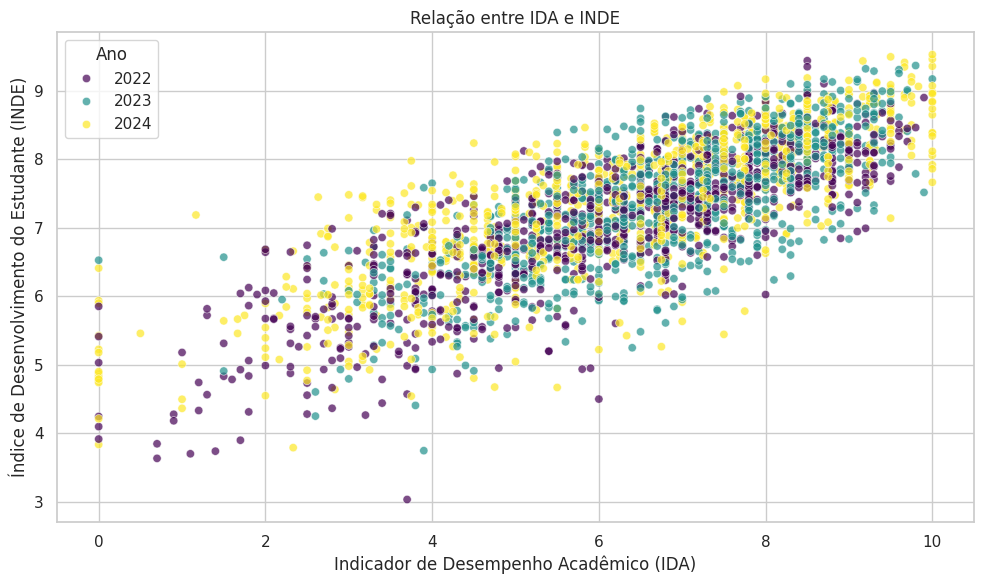

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='IDA', y='INDE', data=df, hue='Ano', palette='viridis', alpha=0.7, ax=ax)
ax.set_title('Relação entre IDA e INDE')
ax.set_xlabel('Indicador de Desempenho Acadêmico (IDA)')
ax.set_ylabel('Índice de Desenvolvimento do Estudante (INDE)')
plt.tight_layout()
plt.show()

## Conclusão

- Engajamento é o principal fator de sucesso
- Defasagem ainda exige atenção prioritária
- Fatores psicossociais impactam diretamente desempenho
- O uso de modelos preditivos pode antecipar riscos

## Insights Estratégicos

### 1. Gênero não é um fator determinante
As diferenças entre alunos do sexo masculino e feminino são mínimas, indicando que o desempenho não está associado ao gênero.

 Implicação: estratégias não precisam ser segmentadas por gênero.

---

### 2. Tempo no programa não garante melhoria contínua
Observa-se que o desempenho melhora nos primeiros anos, mas apresenta queda ao longo do tempo antes de uma leve recuperação.

 Implicação: há um possível efeito de desgaste ou adaptação ao longo do programa.

---

### 3. Alunos de escolas públicas são mais engajados, mas com menor desempenho
Apesar de apresentarem maior engajamento (IEG), alunos de escolas públicas possuem menor desempenho acadêmico (IDA).

 Implicação: o problema não é engajamento, mas base educacional.

---

### 4. O desempenho acadêmico é o principal motor do resultado final
A forte relação entre IDA e INDE confirma que melhorias no desempenho impactam diretamente o resultado global.

 Implicação: foco em aprendizagem gera maior retorno.

---

## Recomendações Estratégicas

- Reforçar suporte pedagógico nas fases iniciais do programa
- Criar estratégias específicas para alunos de escolas públicas (reforço acadêmico)
- Monitorar queda de desempenho ao longo do tempo
- Implementar modelo preditivo para intervenção precoce

---

## Conclusão Final

O programa apresenta impacto positivo, mas ainda enfrenta desafios estruturais relacionados à defasagem inicial, adaptação ao longo do tempo e diferenças de base educacional.

A adoção de uma abordagem orientada por dados e intervenções direcionadas pode potencializar significativamente os resultados.

# **Modelo Preditivo** para Aplicação Prática

#### Objetivo

####Após a análise exploratória dos dados e identificação dos principais fatores associados à defasagem, foi desenvolvido um modelo preditivo com o objetivo de identificar alunos em risco de defasagem de forma antecipada.

####(Pergunta 9), esta etapa foca na construção de um modelo aplicável em contexto real, com maior robustez e capacidade de generalização.

## 9. MODELO PREDITIVO

# **Treinamento, avaliação e salvamento do modelo**

##FEATURE ENGINEERING

In [ ]:
# Definição do target balanceado
threshold = df['IAN'].quantile(0.75)

df['risco_modelo'] = (df['IAN'] >= threshold).astype(int)

features = ['IDA','IEG','IAA','IPS','IPP','Fase_Num','IPV','Anos_No_Programa']

df_model = df.dropna(subset=features + ['risco_modelo']).copy()

X = df_model[features]
y = df_model['risco_modelo']

# Ver distribuição
print(y.value_counts(normalize=True))

risco_modelo
0    0.543073
1    0.456927
Name: proportion, dtype: float64


##SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

##MODELAGEM

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_res, y_res)

RandomForestClassifier(max_depth=8, min_samples_leaf=5, n_estimators=300,
                       random_state=42)

##PROBABILIDADE

In [ ]:
def prever_riscos(novo_aluno):
  prob = model.predict_proba(novo_aluno)[:,1]
  return prob

In [ ]:
# NÃO gerar pred ainda
proba = model.predict_proba(X_test)[:,1]

##BUSCA DO MELHOR THRESHOLD

In [ ]:
from sklearn.metrics import precision_score, recall_score

print("Análise de thresholds (0.4 a 0.7):\n")

for t in [0.4, 0.5, 0.6, 0.7]:
    pred_t = (proba > t).astype(int)

    precision = precision_score(y_test, pred_t, zero_division=0)
    recall = recall_score(y_test, pred_t)

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print("-" * 30)

Análise de thresholds (0.4 a 0.7):

Threshold: 0.4
Precision: 0.56
Recall: 0.86
------------------------------
Threshold: 0.5
Precision: 0.68
Recall: 0.59
------------------------------
Threshold: 0.6
Precision: 0.78
Recall: 0.37
------------------------------
Threshold: 0.7
Precision: 0.86
Recall: 0.20
------------------------------


##ESCOLHA DO THRESHOLD FINAL

In [ ]:
threshold_final = 0.7  # AJUSTAR COM BASE NO RESULTADO

pred = (proba > threshold_final).astype(int)

##AVALIAÇÃO FINAL

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, pred))

roc = roc_auc_score(y_test, proba)
print(f"ROC-AUC: {roc:.3f}")

              precision    recall  f1-score   support

           0       0.59      0.97      0.74       324
           1       0.86      0.20      0.33       272

    accuracy                           0.62       596
   macro avg       0.73      0.59      0.53       596
weighted avg       0.71      0.62      0.55       596

ROC-AUC: 0.751


## Matriz de confusão

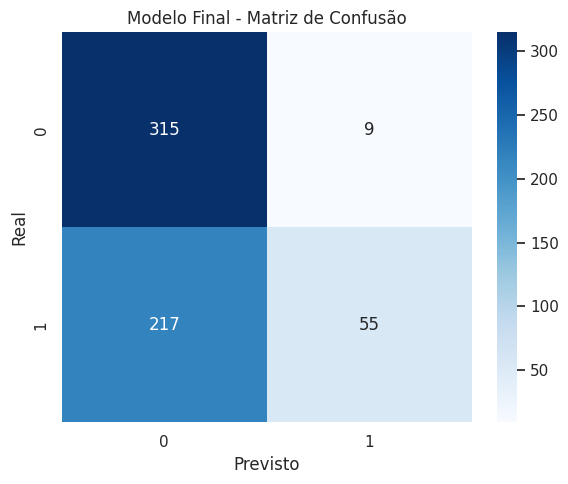

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Modelo Final - Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

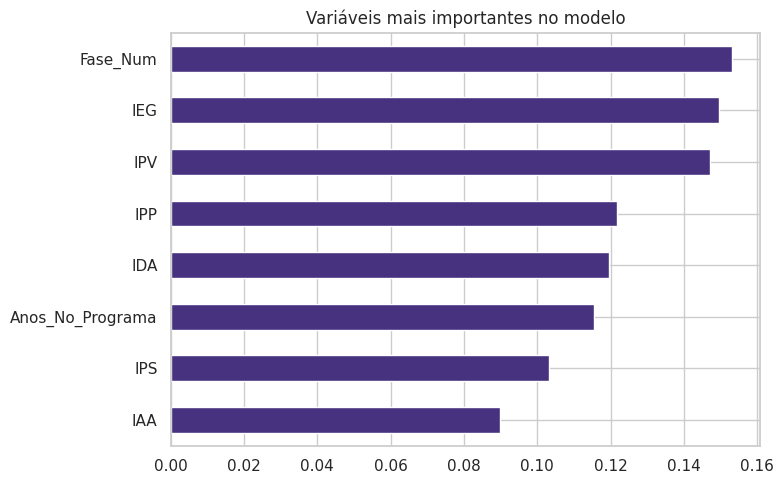

In [ ]:
import pandas as pd

importancias = pd.Series(model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8,5))
importancias.plot(kind='barh')

plt.title("Variáveis mais importantes no modelo")

plt.tight_layout()
plt.show()

##Streamlit

In [ ]:
def prever_risco(novo_aluno_df, threshold=0.75):
    prob = model.predict_proba(novo_aluno_df)[:,1]
    pred = (prob > threshold).astype(int)
    return prob, pred

## 📌 Conclusão do Modelo

Após ajustes na seleção de variáveis, removendo possíveis fontes de vazamento de informação, o modelo apresentou melhora significativa na capacidade de generalização (ROC-AUC ≈ 0.75).

O modelo foi calibrado para priorizar alta precisão (≈ 86%), reduzindo a ocorrência de falsos positivos, conforme objetivo definido.

Essa configuração implica em menor recall (≈ 20%), ou seja, o modelo identifica apenas os casos mais evidentes de risco.

---

## 🎯 Insight

O modelo indica que fatores como fase no programa e engajamento possuem maior influência no risco de defasagem do que variáveis puramente acadêmicas.

---

## 🚀 Considerações

A escolha do limiar de decisão reflete um trade-off entre precisão e cobertura, alinhado com a estratégia de minimizar falsos positivos.